<!-- # | Step               | Description                                        |
| ------------------ | -------------------------------------------------- |
| Data cleaning      | Fix missing data, feature engineering (logs, etc.) |
| Split dataset      | Train-test split                                   |
| Build pipeline     | Create preprocessing + model pipeline              |
| Optional: SMOTE    | Apply SMOTE on training data inside pipeline       |
| Cross-validation   | Use CV to tune hyperparameters                     |
| Train final model  | Fit pipeline on full training data                 |
| Threshold tuning   | Find optimal classification threshold              |
| Evaluate test data | Apply pipeline and evaluate on test set            | -->


## Step               | Description                                        |
- ------------------ | -------------------------------------------------- |
- Data cleaning      | Fix missing data, feature engineering (logs, etc.) |
- Split dataset      | Train-test split                                   |
- Build pipeline     | Create preprocessing + model pipeline              |
- Optional: SMOTE    | Apply SMOTE on training data inside pipeline       |
- Cross-validation   | Use CV to tune hyperparameters                     |
- Train final model  | Fit pipeline on full training data                 |
- Threshold tuning   | Find optimal classification threshold              |
- Evaluate test data | Apply pipeline and evaluate on test set            |


# Steps:
1. Loading the cleaned data
2. Splitting into train/test (test set {X_test, y_test} is held out for final evaluation)
3. Building the pipeline (in this pipeline we only apply preprocessing to the input features and not the target features)
- Log transformation is already done
- Scale numerical features
- Ordinal encode multi-categorical features
- Binary encode Yes/No columns
4. SMOTE (optional)
5. Cross-validation - (for Model tuning, validation, selection - only on train portion X_train)
6. Threshold tuning
7. Model training and evaluation

In [18]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable


## Step 1. Imports

In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.svm import SVC

## Step 2. Load cleaned Data

In [2]:
df = pd.read_csv("data/cleaned_data.csv")

In [7]:
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,...,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Weight_(kg)_log,BMI_log,Alcohol_Consumption_log,Fruit_Consumption_log,Green_Vegetables_Consumption_log,FriedPotato_Consumption_log
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,...,0,30,16,12,3.516310,2.743417,0.000000,3.433987,2.833213,2.564949
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,...,0,30,0,4,4.358118,3.377246,0.000000,3.433987,0.000000,1.609438
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,...,4,12,3,16,4.493680,3.540089,1.609438,2.564949,1.386294,2.833213
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,...,0,30,30,8,4.547965,3.392157,0.000000,3.433987,3.433987,2.197225
4,Good,Within the past year,No,No,No,No,No,No,No,Male,...,0,8,4,0,4.493680,3.233567,0.000000,2.197225,1.609438,0.000000


In [3]:
# Split into features and target (X, y)
X = df.drop('Heart_Disease', axis=1)
df['Heart_Disease'] = df['Heart_Disease'].replace({'Yes': 1, 'No': 0})
y=df['Heart_Disease']

C:\Users\jsrri\AppData\Local\Temp\ipykernel_20784\2509743869.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Heart_Disease'] = df['Heart_Disease'].replace({'Yes': 1, 'No': 0})


In [4]:
X

,General_Health,Checkup,Exercise,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,...,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Weight_(kg)_log,BMI_log,Alcohol_Consumption_log,Fruit_Consumption_log,Green_Vegetables_Consumption_log,FriedPotato_Consumption_log
0,Poor,Within the past 2 years,No,No,No,No,No,Yes,Female,70-74,...,0,30,16,12,3.516310,2.743417,0.000000,3.433987,2.833213,2.564949
1,Very Good,Within the past year,No,No,No,No,Yes,No,Female,70-74,...,0,30,0,4,4.358118,3.377246,0.000000,3.433987,0.000000,1.609438
2,Very Good,Within the past year,Yes,No,No,No,Yes,No,Female,60-64,...,4,12,3,16,4.493680,3.540089,1.609438,2.564949,1.386294,2.833213
3,Poor,Within the past year,Yes,No,No,No,Yes,No,Male,75-79,...,0,30,30,8,4.547965,3.392157,0.000000,3.433987,3.433987,2.197225
4,Good,Within the past year,No,No,No,No,No,No,Male,80+,...,0,8,4,0,4.493680,3.233567,0.000000,2.197225,1.609438,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308769,Very Good,Within the past year,Yes,No,No,No,No,No,Male,25-29,...,4,30,8,0,4.414615,3.402863,1.609438,3.433987,2.197225,0.000000
308770,Fair,Within the past 5 years,Yes,No,No,No,Yes,No,Male,65-69,...,8,15,60,4,4.260565,3.112626,2.197225,2.772589,4.110874,1.609438
308771,Very Good,5 or more years ago,Yes,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,...,4,40,8,4,4.130837,3.246102,1.609438,3.713572,2.197225,1.609438
308772,Very Good,Within the past year,Yes,No,No,No,No,No,Male,65-69,...,3,30,12,0,4.386765,3.208017,1.386294,3.433987,2.564949,0.000000


In [5]:
y.head()

0    0
1    1
2    0
3    1
4    0
Name: Heart_Disease, dtype: int64

In [6]:
# Split into training and testing sets
# stratify=y ensures class balance in both train and test sets (very important for classification).
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42     
)

In [12]:
X_train.head()

,General_Health,Checkup,Exercise,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,...,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Weight_(kg)_log,BMI_log,Alcohol_Consumption_log,Fruit_Consumption_log,Green_Vegetables_Consumption_log,FriedPotato_Consumption_log
282865,Very Good,Within the past year,Yes,No,No,No,No,Yes,Male,50-54,...,0,0,4,16,3.836437,2.929058,0.000000,0.000000,1.609438,2.833213
182200,Very Good,Within the past year,Yes,No,No,Yes,Yes,Yes,Female,80+,...,0,10,4,0,4.340553,3.420346,0.000000,2.397895,1.609438,0.000000
248183,Excellent,Within the past year,Yes,No,No,No,No,No,Female,35-39,...,0,0,3,30,4.322675,3.497416,0.000000,0.000000,1.386294,3.433987
186752,Very Good,Within the past year,Yes,Yes,No,No,No,No,Male,70-74,...,30,30,15,8,4.493680,3.312366,3.433987,3.433987,2.772589,2.197225
298632,Very Good,Within the past year,Yes,Yes,No,No,Yes,Yes,Male,65-69,...,0,10,4,1,4.386765,3.289893,0.000000,2.397895,1.609438,0.693147


In [25]:
X_test.head()

,General_Health,Checkup,Exercise,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,...,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Weight_(kg)_log,BMI_log,Alcohol_Consumption_log,Fruit_Consumption_log,Green_Vegetables_Consumption_log,FriedPotato_Consumption_log
4408,Good,Within the past year,Yes,No,Yes,No,No,Yes,Male,65-69,...,15,12,20,24,4.739701,3.722072,2.772589,2.564949,3.044522,3.218876
44320,Very Good,5 or more years ago,No,No,No,No,No,No,Male,35-39,...,30,60,16,8,4.927109,3.763987,3.433987,4.110874,2.833213,2.197225
106573,Good,Within the past year,Yes,Yes,No,Yes,No,No,Female,50-54,...,4,16,4,8,4.267037,3.318178,1.609438,2.833213,1.609438,2.197225
233080,Poor,Within the past year,Yes,No,No,No,Yes,Yes,Female,60-64,...,0,60,4,3,4.739701,3.782142,0.000000,4.110874,1.609438,1.386294
9555,Excellent,Within the past 2 years,Yes,No,No,No,No,Yes,Male,60-64,...,0,30,4,8,4.328626,3.233567,0.000000,3.433987,1.609438,2.197225


In [13]:
y_train.shape

(247019,)

In [14]:
y_test.head()

4408      1
44320     0
106573    0
233080    0
9555      0
Name: Heart_Disease, dtype: int64

## Step 3: Define feature types

In [7]:
# Binary features still in object type
binary_cols = ['Exercise', 'Skin_Cancer', 'Other_Cancer',
               'Depression', 'Arthritis', 'Smoking_History']

# Categorical Ordinal features
ordinal_cols = ['General_Health', 'Checkup', 'Age_Category', 'Sex', 'Diabetes']

# Custom order for ordinal encoder
ordinal_mapping = [
    ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'],             # General_Health
    ['Never', '5 or more years ago', 'Within the past 5 years',
     'Within the past 2 years', 'Within the past year'],            # Checkup
    ['18-24', '25-29', '30-34', '35-39', '40-44',
     '45-49', '50-54', '55-59', '60-64', '65-69',
     '70-74', '75-79', '80+'],                                      # Age_Category
    ['Female', 'Male'],                                             # Sex
    ['No', 'No, pre-diabetes or borderline diabetes',
     'Yes, but female told only during pregnancy', 'Yes']           # Diabetes
]

# Numerical columns (already include log-transformed ones)
num_cols = [
    'Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption',
    'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption',
    'Weight_(kg)_log', 'BMI_log', 'Alcohol_Consumption_log', 'Fruit_Consumption_log',
    'Green_Vegetables_Consumption_log', 'FriedPotato_Consumption_log'
]


## Step 4: Custom Binary Encoder or Transformer

In [8]:
class BinaryEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mapping = {'Yes': 1, 'No': 0}
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.replace(self.mapping).astype(int)

## Step 5: Build Preprocessing Pipeline on X_train only

In [9]:
# Pipeline for numeric data
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Pipeline for binary categorical data
binary_pipeline = Pipeline([
    ('binary_encoder', BinaryEncoder())
])

# Pipeline for ordinal features
ordinal_pipeline = Pipeline([
    ('ordinal_encoder', OrdinalEncoder(categories=ordinal_mapping))
])

# Full preprocessor
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('bin', binary_pipeline, binary_cols),
    ('ord', ordinal_pipeline, ordinal_cols)
])


In [16]:
# n_splits = 3, smote = False, models included- LogisticRegression, RandomForest, XGBoost, SVM
# Step 1: Load your cleaned data (assumed done)
# Step 2: train/test split (assumed done: X_train, X_test, y_train, y_test)
# Step 3-6: preprocessing pipeline ready and defined as 'preprocessor'

# Optional: set smote usage
use_smote = False  # change to True to enable SMOTE


# Define your models
models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, iterations=30, random_seed=42)
    # 'SVM': SVC(probability=True, class_weight='balanced', random_state=42)
}

# Function to build pipeline for a model
def build_pipeline(model, use_smote=False):
    steps = [('preprocessing', preprocessor)]
    if use_smote:
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('classifier', model))
    return ImbPipeline(steps=steps)

# Store results
results = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Loop over models
for model_name, model in models.items():
    print(f"\nTraining and evaluating {model_name}...")
    start_time = time.time()
    
    pipeline = build_pipeline(model, use_smote=use_smote)

    # Step 7: Cross-validation (on training data only)
    print(" Starting cross-validation...")
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"Average ROC AUC (CV): {scores.mean():.4f}")
    
    # Step 8: Fit on train data
    print(" Fitting model on full training data...")
    pipeline.fit(X_train, y_train)
    print(" Model training complete.")
    
    # Step 9: Predict probabilities on test data
    print(" Predicting probabilities on test data...")
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Step 10: Threshold tuning & evaluation
    print("Threshold tuning results:")
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1 = 0
    best_thresh = 0.5
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        print(f"Threshold: {thresh:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    end_time = time.time()
    elapsed = end_time - start_time
    print(f" Time taken for {model_name}: {elapsed:.2f} seconds")
    
    results[model_name] = {'cv_auc':scores.mean(), 'best_threshold': best_thresh, 'best_f1': best_f1}

# Summary of best thresholds and F1 scores
print("\nSummary of best thresholds and F1 scores:")
for model_name, res in results.items():
    print(f"{model_name}: CV AUC ={res['cv_auc']:.4f}, Best Threshold = {res['best_threshold']}, Best F1 Score = {res['best_f1']:.3f}")



Training and evaluating LogisticRegression...
 Starting cross-validation...


C:\Users\jsrri\AppData\Local\Temp\ipykernel_16268\668706862.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping)
C:\Users\jsrri\AppData\Local\Temp\ipykernel_16268\668706862.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping)
C:\Users\jsrri\.conda\envs\myenv\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an e

Average ROC AUC (CV): 0.8342
 Fitting model on full training data...


C:\Users\jsrri\AppData\Local\Temp\ipykernel_16268\668706862.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping)


 Model training complete.
 Predicting probabilities on test data...
Threshold tuning results:


...

C:\Users\jsrri\AppData\Local\Temp\ipykernel_16268\668706862.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping)
C:\Users\jsrri\.conda\envs\myenv\lib\site-packages\xgboost\training.py:183: UserWarning: [12:58:25] WARNING: D:\bld\xgboost-split_1758007502304\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 Model training complete.
 Predicting probabilities on test data...


C:\Users\jsrri\AppData\Local\Temp\ipykernel_16268\668706862.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping)
C:\Users\jsrri\.conda\envs\myenv\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Threshold tuning results:
Threshold: 0.10 | Precision: 0.220 | Recall: 0.747 | F1: 0.340
Threshold: 0.15 | Precision: 0.262 | Recall: 0.613 | F1: 0.367
Threshold: 0.20 | Precision: 0.301 | Recall: 0.475 | F1: 0.369
Threshold: 0.25 | Precision: 0.335 | Recall: 0.354 | F1: 0.344
Threshold: 0.30 | Precision: 0.376 | Recall: 0.265 | F1: 0.311
Threshold: 0.35 | Precision: 0.404 | Recall: 0.190 | F1: 0.258
Threshold: 0.40 | Precision: 0.435 | Recall: 0.129 | F1: 0.199
Threshold: 0.45 | Precision: 0.473 | Recall: 0.087 | F1: 0.147
Threshold: 0.50 | Precision: 0.493 | Recall: 0.053 | F1: 0.095
Threshold: 0.55 | Precision: 0.528 | Recall: 0.032 | F1: 0.061
Threshold: 0.60 | Precision: 0.584 | Recall: 0.019 | F1: 0.036
Threshold: 0.65 | Precision: 0.606 | Recall: 0.008 | F1: 0.016
Threshold: 0.70 | Precision: 0.586 | Recall: 0.003 | F1: 0.007
Threshold: 0.75 | Precision: 0.400 | Recall: 0.000 | F1: 0.001
Threshold: 0.80 | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Threshold: 0.85 | Precision: 

C:\Users\jsrri\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jsrri\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
# n_splits = 5, smote = False, models included- LogisticRegression, RandomForest, XGBoost, CatBoost
# Step 1: Load your cleaned data (assumed done)
# Step 2: train/test split (assumed done: X_train, X_test, y_train, y_test)
# Step 3-6: preprocessing pipeline ready and defined as 'preprocessor'

# Optional: set smote usage
use_smote = False  # change to True to enable SMOTE


# Define your models
models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, iterations=30, random_seed=42)
    # 'SVM': SVC(probability=True, class_weight='balanced', random_state=42)
}

# Function to build pipeline for a model
def build_pipeline(model, use_smote=False):
    steps = [('preprocessing', preprocessor)]
    if use_smote:
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('classifier', model))
    return ImbPipeline(steps=steps)

# Store results
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop over models
for model_name, model in models.items():
    print(f"\nTraining and evaluating {model_name}...")
    start_time = time.time()
    
    pipeline = build_pipeline(model, use_smote=use_smote)

    # Step 7: Cross-validation (on training data only)
    print(" Starting cross-validation...")
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"Average ROC AUC (CV): {scores.mean():.4f}")
    
    # Step 8: Fit on train data
    print(" Fitting model on full training data...")
    pipeline.fit(X_train, y_train)
    print(" Model training complete.")
    
    # Step 9: Predict probabilities on test data
    print(" Predicting probabilities on test data...")
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Step 10: Threshold tuning & evaluation
    print("Threshold tuning results:")
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1 = 0
    best_thresh = 0.5
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        print(f"Threshold: {thresh:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    end_time = time.time()
    elapsed = end_time - start_time
    print(f" Time taken for {model_name}: {elapsed:.2f} seconds")
    
    results[model_name] = {'cv_auc':scores.mean(), 'best_threshold': best_thresh, 'best_f1': best_f1}

# Summary of best thresholds and F1 scores
print("\nSummary of best thresholds and F1 scores:")
for model_name, res in results.items():
    print(f"{model_name}: CV AUC ={res['cv_auc']:.4f}, Best Threshold = {res['best_threshold']}, Best F1 Score = {res['best_f1']:.3f}")



Training and evaluating LogisticRegression...
 Starting cross-validation...


C:\Users\jsrri\AppData\Local\Temp\ipykernel_20784\1671304598.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping).astype(int)
C:\Users\jsrri\AppData\Local\Temp\ipykernel_20784\1671304598.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping).astype(int)
C:\Users\jsrri\.conda\envs\myenv\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict,

Average ROC AUC (CV): 0.8342
 Fitting model on full training data...


C:\Users\jsrri\AppData\Local\Temp\ipykernel_20784\1671304598.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping).astype(int)


 Model training complete.
 Predicting probabilities on test data...


...

C:\Users\jsrri\AppData\Local\Temp\ipykernel_20784\1671304598.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping).astype(int)


 Model training complete.
 Predicting probabilities on test data...


C:\Users\jsrri\AppData\Local\Temp\ipykernel_20784\1671304598.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping).astype(int)
C:\Users\jsrri\.conda\envs\myenv\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Threshold tuning results:
Threshold: 0.10 | Precision: 0.221 | Recall: 0.765 | F1: 0.343
Threshold: 0.15 | Precision: 0.268 | Recall: 0.617 | F1: 0.374
Threshold: 0.20 | Precision: 0.305 | Recall: 0.467 | F1: 0.369
Threshold: 0.25 | Precision: 0.349 | Recall: 0.356 | F1: 0.352
Threshold: 0.30 | Precision: 0.388 | Recall: 0.257 | F1: 0.309
Threshold: 0.35 | Precision: 0.428 | Recall: 0.178 | F1: 0.251
Threshold: 0.40 | Precision: 0.462 | Recall: 0.120 | F1: 0.191
Threshold: 0.45 | Precision: 0.487 | Recall: 0.074 | F1: 0.129
Threshold: 0.50 | Precision: 0.491 | Recall: 0.039 | F1: 0.073
Threshold: 0.55 | Precision: 0.525 | Recall: 0.021 | F1: 0.040
Threshold: 0.60 | Precision: 0.557 | Recall: 0.010 | F1: 0.019
Threshold: 0.65 | Precision: 0.500 | Recall: 0.003 | F1: 0.006
Threshold: 0.70 | Precision: 0.500 | Recall: 0.001 | F1: 0.002
Threshold: 0.75 | Precision: 0.333 | Recall: 0.000 | F1: 0.000
Threshold: 0.80 | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Threshold: 0.85 | Precision: 

C:\Users\jsrri\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jsrri\.conda\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


- Model              | CV AUC | Best F1   | Best Threshold |
- ------------------ | ------ | --------- | -------------- |
- LogisticRegression | 0.8342 | **0.374** | \~0.70         |
- CatBoost           | 0.8344 | **0.374** | \~0.15         |
- XGBoost            | 0.8283 | 0.369     | \~0.20         |
- RandomForest       | 0.8108 | 0.354     | \~0.15         |
  
Logistic Regression performs just as well as the best gradient boosting model (CatBoost), and is far easier to interpret and deploy. We’ve tuned the threshold and validated it well — so it’s a strong, justifiable final model. we found Best Threshold = 0.70 for current Logistic Regression setup (class_weight='balanced', CV=5, SMOTE=False)- Best performing and most interpretable model.

In [21]:
# n_splits = 5, smote = True, models included- LogisticRegression, RandomForest, XGBoost, CatBoost
# Step 1: Load your cleaned data (assumed done)
# Step 2: train/test split (assumed done: X_train, X_test, y_train, y_test)
# Step 3-6: preprocessing pipeline ready and defined as 'preprocessor'

# Optional: set smote usage
use_smote =   # change to True to enable SMOTE


# Define your models
models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, iterations=30, random_seed=42)
    # 'SVM': SVC(probability=True, class_weight='balanced', random_state=42)
}

# Function to build pipeline for a model
def build_pipeline(model, use_smote=False):
    steps = [('preprocessing', preprocessor)]
    if use_smote:
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('classifier', model))
    return ImbPipeline(steps=steps)

# Store results
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop over models
for model_name, model in models.items():
    print(f"\nTraining and evaluating {model_name}...")
    start_time = time.time()
    
    pipeline = build_pipeline(model, use_smote=use_smote)

    # Step 7: Cross-validation (on training data only)
    print(" Starting cross-validation...")
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"Average ROC AUC (CV): {scores.mean():.4f}")
    
    # Step 8: Fit on train data
    print(" Fitting model on full training data...")
    pipeline.fit(X_train, y_train)
    print(" Model training complete.")
    
    # Step 9: Predict probabilities on test data
    print(" Predicting probabilities on test data...")
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Step 10: Threshold tuning & evaluation
    print("Threshold tuning results:")
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1 = 0
    best_thresh = 0.5
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        print(f"Threshold: {thresh:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    end_time = time.time()
    elapsed = end_time - start_time
    print(f" Time taken for {model_name}: {elapsed:.2f} seconds")
    
    results[model_name] = {'cv_auc':scores.mean(), 'best_threshold': best_thresh, 'best_f1': best_f1}

# Summary of best thresholds and F1 scores
print("\nSummary of best thresholds and F1 scores:")
for model_name, res in results.items():
    print(f"{model_name}: CV AUC ={res['cv_auc']:.4f}, Best Threshold = {res['best_threshold']}, Best F1 Score = {res['best_f1']:.3f}")



Training and evaluating LogisticRegression...
 Starting cross-validation...


C:\Users\jsrri\AppData\Local\Temp\ipykernel_16268\668706862.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping)
C:\Users\jsrri\AppData\Local\Temp\ipykernel_16268\668706862.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping)
C:\Users\jsrri\.conda\envs\myenv\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an e

Average ROC AUC (CV): 0.8324
 Fitting model on full training data...


C:\Users\jsrri\AppData\Local\Temp\ipykernel_16268\668706862.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping)


 Model training complete.
 Predicting probabilities on test data...


...

Average ROC AUC (CV): 0.8291
 Fitting model on full training data...


C:\Users\jsrri\AppData\Local\Temp\ipykernel_16268\668706862.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping)


 Model training complete.
 Predicting probabilities on test data...


C:\Users\jsrri\AppData\Local\Temp\ipykernel_16268\668706862.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping)
C:\Users\jsrri\.conda\envs\myenv\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Threshold tuning results:
Threshold: 0.10 | Precision: 0.206 | Recall: 0.801 | F1: 0.328
Threshold: 0.15 | Precision: 0.248 | Recall: 0.668 | F1: 0.362
Threshold: 0.20 | Precision: 0.286 | Recall: 0.537 | F1: 0.373
Threshold: 0.25 | Precision: 0.319 | Recall: 0.409 | F1: 0.358
Threshold: 0.30 | Precision: 0.351 | Recall: 0.309 | F1: 0.329
Threshold: 0.35 | Precision: 0.389 | Recall: 0.224 | F1: 0.284
Threshold: 0.40 | Precision: 0.425 | Recall: 0.159 | F1: 0.232
Threshold: 0.45 | Precision: 0.454 | Recall: 0.102 | F1: 0.167
Threshold: 0.50 | Precision: 0.473 | Recall: 0.062 | F1: 0.110
Threshold: 0.55 | Precision: 0.475 | Recall: 0.032 | F1: 0.061
Threshold: 0.60 | Precision: 0.506 | Recall: 0.016 | F1: 0.032
Threshold: 0.65 | Precision: 0.460 | Recall: 0.008 | F1: 0.016
Threshold: 0.70 | Precision: 0.512 | Recall: 0.004 | F1: 0.009
Threshold: 0.75 | Precision: 0.450 | Recall: 0.002 | F1: 0.004
Threshold: 0.80 | Precision: 0.200 | Recall: 0.000 | F1: 0.000
Threshold: 0.85 | Precision: 

## Evaluate on Test set (Final metrics)

In [12]:
from sklearn.metrics import confusion_matrix, roc_auc_score
best_threshold = 0.7

# Refit pipeline (if needed)
pipeline = build_pipeline(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
pipeline.fit(X_train, y_train)

# Predict probabilities
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba >= best_threshold).astype(int)

# Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred_final))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


C:\Users\jsrri\AppData\Local\Temp\ipykernel_20784\1671304598.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping).astype(int)


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92     56761
           1       0.29      0.53      0.37      4994

    accuracy                           0.86     61755
   macro avg       0.62      0.71      0.65     61755
weighted avg       0.90      0.86      0.87     61755

Confusion Matrix:
[[50217  6544]
 [ 2341  2653]]
ROC AUC: 0.8391214045568763


C:\Users\jsrri\AppData\Local\Temp\ipykernel_20784\1671304598.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(self.mapping).astype(int)
C:\Users\jsrri\.conda\envs\myenv\lib\site-packages\sklearn\pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


## Plot AUC & Precision-Recall Curves

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import roc_curve, auc, precision_recall_curve

def plot_auc_pr_curves(y_test, y_proba, model_name):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    plt.figure(figsize=(12, 5))

    # ROC Curve
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='lower right')

    # Precision-Recall Curve
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='blue', lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')

    plt.tight_layout()
    plt.show()


## Hyperparameter tuning with GridSearchCV
Example param_grid for Logistic Regression
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}


In [22]:
from sklearn.model_selection import GridSearchCV

def perform_grid_search(pipeline, param_grid, X_train, y_train, scoring='f1'):
    grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=3, scoring=scoring, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    return grid_search


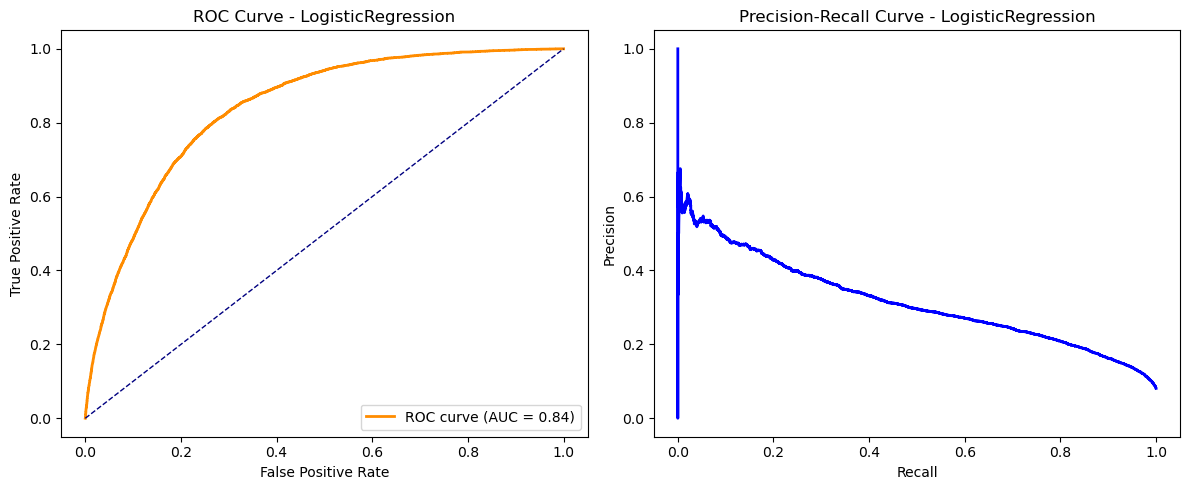

In [18]:
plot_auc_pr_curves(y_test, y_proba, "LogisticRegression")




In [19]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(y_test, y_proba)
print(f"Average Precision Score: {ap:.4f}")

Average Precision Score: 0.3152


## Save the best model

In [15]:
import joblib

def save_model(model, filename='best_model.pkl'):
    joblib.dump(model, filename)
save_model(pipeline, "logreg_best.pkl")